# NVIDIA ALCHEMI Batched Molecular Dynamics (BMD): From Unit Cells to Thermodynamic Metrics

This playbook demonstrates an end-to-end materials science workflow using NVIDIA ALCHEMI's
GPU-accelerated **Batched Molecular Dynamics (BMD)** and **Batch Geometry Relaxation (BGR)**
NIM-style microservices — from crystallographic unit cell construction through thermodynamic
property extraction.


## What You Will Learn

1. **Connect** to the ALCHEMI BMD/BGR REST endpoints and verify availability
2. **Build** crystalline supercells programmatically with pymatgen
3. **Run NVT/NPT** molecular dynamics via single API calls
4. **Extract properties**: density, RDF, MSD, diffusion coefficient, thermal expansion
5. **Batch** simulations for temperature sweeps
6. **Switch MLIPs** with a one-line parameter change

> **Prerequisites**
>
> - NVIDIA ALCHEMI BMD NIM running on `localhost:{BMD_PORT}` **or** cached responses in `cached_responses/`
> - NVIDIA ALCHEMI BGR NIM running on `localhost:{BGR_PORT}` **or** cached responses in `cached_responses/`
> - Python ≥ 3.11 with packages from `environment.yml`
> - ~5 min for FAST_DEMO, ~30 min for full production runs

---
## 1. Environment Setup & Control Panel

In [1]:
# --- Imports and version check ---
import sys
import os
import warnings
import importlib.util
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=DeprecationWarning)

_missing = []
for _pkg in ["ase", "pymatgen", "pydantic", "requests", "rdkit"]:
    try:
        __import__(_pkg)
    except ImportError:
        _missing.append(_pkg)

# OVITO is optional for rendering
OVITO_AVAILABLE = importlib.util.find_spec("ovito") is not None

if _missing:
    print(f"Missing packages: {_missing}")
    print("Install with: pip install " + " ".join(_missing))
else:
    from importlib.metadata import version as _pkg_version

    print("All required packages available.")
    print(f"  ASE {_pkg_version('ase')}")
    print(f"  pymatgen {_pkg_version('pymatgen')}")
    print(f"  pydantic {_pkg_version('pydantic')}")

All required packages available.
  ASE 3.27.0
  pymatgen 2025.10.7
  pydantic 2.12.5


In [2]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║                      CONTROL PANEL                             ║
# ║  Adjust these parameters to control simulation behaviour.      ║
# ╚══════════════════════════════════════════════════════════════════╝

# --- Demo mode ---
FAST_DEMO = False  # True: short sims + cached responses

# --- Endpoint ---
BMD_PORT = 8000  # BMD NIM port
BGR_PORT = 8890  # BGR NIM port
BMD_SERVER_URL = f"http://localhost:{BMD_PORT}"
BGR_SERVER_URL = f"http://localhost:{BGR_PORT}"

# --- MD parameters ---
T_KELVIN = 300.0  # Target temperature (K)
P_KBAR = 0.0  # External pressure (kBar) — 0 = ambient
DT_FS = 1.0  # Integration timestep (fs)
FRICTION = 1.0  # Langevin friction (ps^-1)
SEED = 42  # RNG seed for reproducibility

# --- Simulation lengths (gated by FAST_DEMO) ---
NSTEPS_EQUIL = 200 if FAST_DEMO else 5000
NSTEPS_PROD = 500 if FAST_DEMO else 10000
SAVE_INTERVAL = 10 if FAST_DEMO else 100

# --- Structure ---
SUPERCELL_DIMS = (2, 2, 2) if FAST_DEMO else (3, 3, 3)

# --- Temperature sweep ---
TEMPERATURES = [200, 300, 400] if FAST_DEMO else [200, 250, 300, 350, 400, 450, 500]

# --- Paths ---
CACHE_DIR = "cached_responses/materials"
OUTPUT_DIR = "outputs"
STRUCTURE_DIR = "structures"

print(f"FAST_DEMO = {FAST_DEMO}")
print(f"Equilibration: {NSTEPS_EQUIL} steps | Production: {NSTEPS_PROD} steps")
print(f"Supercell: {SUPERCELL_DIMS} | Temperatures: {TEMPERATURES}")

FAST_DEMO = False
Equilibration: 5000 steps | Production: 10000 steps
Supercell: (3, 3, 3) | Temperatures: [200, 250, 300, 350, 400, 450, 500]


In [3]:
# --- Helper imports and directory setup ---
sys.path.insert(0, ".")
from helpers import (
    MDAtomicData,
    MDConfig,
    MDRequest,
    ase_to_atomic_data,
    atomic_data_to_ase,
    check_endpoint,
    run_md_or_load_cache,
    run_bgr_or_load_cache,
    extract_thermo_timeseries,
    trajectory_to_ase_list,
    compute_rdf,
    compute_msd,
    estimate_diffusion_coefficient,
    compute_density,
    thermal_expansion_proxy,
    pick_production_window,
)
from helpers.models import ase_to_md_atomic_data

if OVITO_AVAILABLE:
    from helpers import render_structure_ovito, display_inline, structure_summary_table
else:
    from helpers import structure_summary_table

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)
print("Helpers loaded. Output directories ready.")

Helpers loaded. Output directories ready.


---
## 2. Endpoint Connectivity & API Hello World

Before running simulations we verify the BMD NIM is reachable. If it isn't, every
subsequent cell will fall back to cached responses (when `FAST_DEMO = True`).

In [4]:
BMD_ENDPOINT_LIVE = check_endpoint(BMD_SERVER_URL)
if BMD_ENDPOINT_LIVE:
    print(f"BMD endpoint is LIVE at {BMD_SERVER_URL}")
else:
    print(
        f"BMD endpoint NOT reachable at {BMD_SERVER_URL} — will use cached responses."
    )
BGR_ENDPOINT_LIVE = check_endpoint(BGR_SERVER_URL)
if BGR_ENDPOINT_LIVE:
    print(f"BGR endpoint is LIVE at {BGR_SERVER_URL}")
else:
    print(
        f"BGR endpoint NOT reachable at {BGR_SERVER_URL} — will use cached responses."
    )

BMD endpoint is LIVE at http://localhost:8000


BGR endpoint is LIVE at http://localhost:8890


### Request / Response Schema

| Field | Type | Description |
|-------|------|-------------|
| `atoms.coord` | `List[float]` | Flattened xyz coordinates (Å) |
| `atoms.numbers` | `List[int]` | Atomic numbers |
| `atoms.cell` | `List[float]` | 3×3 flattened lattice vectors (Å) |
| `atoms.pbc` | `List[bool]` | Periodic boundary conditions |
| `atoms.velocity` | `List[float]` | Flattened velocities (Å/fs) |
| `config.temperature` | `float` | Target temperature (K) |
| `config.dt` | `float` | Timestep (fs) |
| `config.nvt` / `config.npt` | `bool` | Thermostat / barostat toggles |
| `config.md_time_max` | `float` | Simulation end time (ps) |
| `config.save_interval` | `int` | Frames saved every N steps |
| **Response** | | |
| `trajectory[].energy` | `float` | Potential energy (eV) |
| `trajectory[].coord` | `List[float]` | Updated coordinates |
| `trajectory[].velocity` | `List[float]` | Updated velocities |
| `trajectory[].cell` | `List[float]` | Updated cell (NPT) |
| `trajectory[].stress` | `List[float]` | Virial stress tensor (eV/Å³) |

In [5]:
# --- API Hello World: tiny H2 MD ---
h2_atoms = MDAtomicData(
    coord=[0.0, 0.0, 0.0, 0.0, 0.0, 0.74],
    numbers=[1, 1],
    cell=[10.0, 0.0, 0.0, 0.0, 10.0, 0.0, 0.0, 0.0, 10.0],
    pbc=[True, True, True],
)
h2_config = MDConfig(
    temperature=300.0,
    dt=1.0,
    nvt=True,
    npt=False,
    md_time_max=0.01,  # 10 fs
    save_interval=1,
)

h2_reply = run_md_or_load_cache(
    h2_atoms, h2_config, BMD_SERVER_URL, CACHE_DIR, "h2_hello_world", BMD_ENDPOINT_LIVE
)

print(f"Status      : {h2_reply.status}")
print(f"Frames      : {len(h2_reply.trajectory)}")
print(f"Final energy: {h2_reply.trajectory[-1].energy:.6f} eV")

  Loading cached response: h2_hello_world
Status      : Success
Frames      : 11
Final energy: -6.511127 eV


In [6]:
from IPython.display import JSON

# --- Pretty-print request and first response snapshot ---
request_dict = MDRequest(atoms=h2_atoms, config=h2_config).model_dump()
print("=== BMD REQUEST ===")
JSON(request_dict, expanded=False, root="request")

=== BMD REQUEST ===


<IPython.core.display.JSON object>

In [7]:
print("=== RESPONSE FIRST MD SNAPSHOT ===")
md_snapshot_dict = h2_reply.trajectory[0].model_dump()
JSON(md_snapshot_dict, expanded=False, root="response")

=== RESPONSE FIRST MD SNAPSHOT ===


<IPython.core.display.JSON object>

### Common Failure Modes

| Error | Cause | Fix |
|-------|-------|-----|
| `ConnectionError` | NIM not running | Start container on port 8000 |
| `422 Unprocessable` | Malformed request | Check `coord` length = 3 × N |
| `Simulation diverged` | Timestep too large / bad geometry | Reduce `dt`, relax first |
| `Timeout` | Long simulation | Increase timeout or chunk `md_time_max` |

---
## 3. Unit Cell → Supercell → MD-Ready Structure

We build **NaCl** (rock-salt, Fm-3m) as a well-characterised crystalline benchmark:
experimental density ≈ 2.165 g/cm³, first RDF peak ≈ 2.82 Å.

In [8]:
# --- Build NaCl unit cell with pymatgen ---
from pymatgen.core import Lattice, Structure
from pymatgen.io.ase import AseAtomsAdaptor

nacl_struct = Structure.from_spacegroup(
    "Fm-3m",
    Lattice.cubic(5.64),
    ["Na", "Cl"],
    [[0, 0, 0], [0.5, 0.5, 0.5]],
)
print(f"Unit cell: {nacl_struct.composition} — {len(nacl_struct)} atoms")
print(f"Lattice parameter: a = {nacl_struct.lattice.a:.3f} Å")

Unit cell: Na4 Cl4 — 8 atoms
Lattice parameter: a = 5.640 Å


In [9]:
# --- Make supercell and convert to ASE ---
nacl_super = nacl_struct.copy()
nacl_super.make_supercell(SUPERCELL_DIMS)
print(f"Supercell: {SUPERCELL_DIMS} → {len(nacl_super)} atoms")

adaptor = AseAtomsAdaptor()
nacl_ase = adaptor.get_atoms(nacl_super)
print(
    f"ASE Atoms: {nacl_ase.get_chemical_formula()} | Volume: {nacl_ase.get_volume():.1f} Å³"
)
print(f"Coords (first 4 atoms):\n{nacl_ase.get_positions()[:4]}")

Supercell: (3, 3, 3) → 216 atoms
ASE Atoms: Cl108Na108 | Volume: 4844.0 Å³
Coords (first 4 atoms):
[[ 0.    0.    0.  ]
 [ 0.    0.    5.64]
 [ 0.    0.   11.28]
 [ 0.    5.64  0.  ]]


In [10]:
# --- Convert to MDAtomicData and save CIF ---
import ase.io

nacl_md_atoms = ase_to_md_atomic_data(nacl_ase)
print(f"MDAtomicData: {len(nacl_md_atoms.numbers)} atoms")
print(
    f"  coord length: {len(nacl_md_atoms.coord)} (= 3 × {len(nacl_md_atoms.numbers)})"
)
print(f"  PBC: {nacl_md_atoms.pbc}")

cif_path = os.path.join(OUTPUT_DIR, "nacl_supercell.cif")
ase.io.write(cif_path, nacl_ase)
print(f"  Saved: {cif_path}")

MDAtomicData: 216 atoms
  coord length: 648 (= 3 × 216)
  PBC: [True, True, True]
  Saved: outputs/nacl_supercell.cif


In [11]:
# --- Optional: BGR geometry relaxation ---
try:
    nacl_bgr_atom = ase_to_atomic_data(nacl_ase, _id="nacl_supercell")
    bgr_reply = run_bgr_or_load_cache(
        [nacl_bgr_atom],
        BGR_SERVER_URL,
        CACHE_DIR,
        "nacl_bgr_relax",
        BGR_ENDPOINT_LIVE,
        cellopt=True,
    )
    relaxed = atomic_data_to_ase(bgr_reply.atoms[0])
    print(f"BGR converged: {bgr_reply.atoms[0].converged}")
    print(f"Relaxed energy: {bgr_reply.atoms[0].energy:.4f} eV")
    # Use relaxed structure for MD
    nacl_ase = relaxed
    nacl_md_atoms = ase_to_md_atomic_data(nacl_ase)
except Exception as e:
    print(f"BGR skipped: {e}")
    print("Proceeding with unrelaxed supercell.")

  Loading cached response: nacl_bgr_relax
BGR converged: True
Relaxed energy: -216.7383 eV


,Formula,Atoms,a (A),b (A),c (A),Volume (A^3),Density (g/cm^3)
0,Cl32 Na32,64,11.424,11.424,11.424,1490.84,2.083


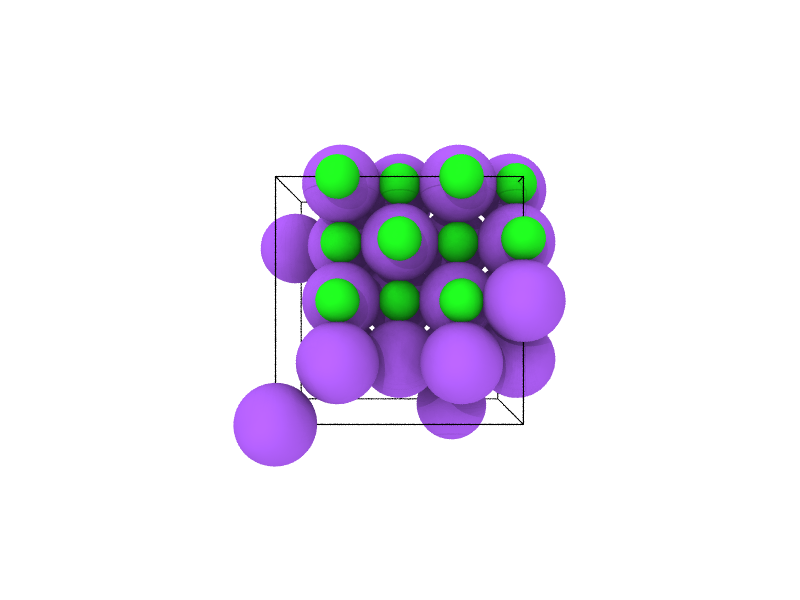

In [12]:
# --- OVITO render + structure summary ---
summary_df = structure_summary_table(nacl_ase)
display(summary_df)

if OVITO_AVAILABLE:
    img_path = render_structure_ovito(
        nacl_ase, os.path.join(OUTPUT_DIR, "nacl_render.png")
    )
    display_inline(img_path)
else:
    print("(OVITO not available — skipping 3D render)")

---
## 4. Run MD — NVT Equilibration → NPT Production

**Workflow:**
1. **NVT equilibration** — Langevin thermostat, fixed cell → thermalise velocities
2. **NPT production** — Langevin thermostat + MC barostat → sample equilibrium ensemble

The MLIP model is selected server-side. Switching models (e.g. MACE-MP-0 → AIMNet2)
requires only restarting the NIM with a different config specified in the `BGR_CONFIG` env variable.

In [13]:
# --- NVT Equilibration ---
equil_time_ps = NSTEPS_EQUIL * DT_FS / 1000.0

nvt_config = MDConfig(
    temperature=T_KELVIN,
    dt=DT_FS,
    nvt=True,
    npt=False,
    friction=FRICTION,
    pressure=P_KBAR,
    md_time_max=equil_time_ps,
    save_interval=SAVE_INTERVAL,
)

nvt_reply = run_md_or_load_cache(
    nacl_md_atoms,
    nvt_config,
    BMD_SERVER_URL,
    CACHE_DIR,
    "nacl_nvt_equil",
    BMD_ENDPOINT_LIVE,
)
print(f"NVT status: {nvt_reply.status} | Frames: {len(nvt_reply.trajectory)}")
print(f"Final E_pot: {nvt_reply.trajectory[-1].energy:.4f} eV")

  Loading cached response: nacl_nvt_equil
NVT status: Success | Frames: 51
Final E_pot: -214.5429 eV


In [14]:
# --- Extract final NVT snapshot → seed NPT ---
last_snap = nvt_reply.trajectory[-1]
npt_atoms = MDAtomicData(
    coord=last_snap.coord,
    numbers=nacl_md_atoms.numbers,
    charge=nacl_md_atoms.charge,
    mult=nacl_md_atoms.mult,
    cell=last_snap.cell if last_snap.cell else nacl_md_atoms.cell,
    pbc=nacl_md_atoms.pbc,
    velocity=last_snap.velocity,
)
print(f"NPT seed: {len(npt_atoms.numbers)} atoms with velocities from NVT")

NPT seed: 64 atoms with velocities from NVT


In [15]:
# --- NPT Production ---
prod_time_ps = NSTEPS_PROD * DT_FS / 1000.0

npt_config = MDConfig(
    temperature=T_KELVIN,
    dt=DT_FS,
    nvt=True,
    npt=True,
    friction=FRICTION,
    pressure=P_KBAR,
    md_time_max=prod_time_ps,
    save_interval=SAVE_INTERVAL,
)

npt_reply = run_md_or_load_cache(
    npt_atoms,
    npt_config,
    BMD_SERVER_URL,
    CACHE_DIR,
    "nacl_npt_prod",
    BMD_ENDPOINT_LIVE,
    timeout=1800,
)
print(f"NPT status: {npt_reply.status} | Frames: {len(npt_reply.trajectory)}")
print(f"Final E_pot: {npt_reply.trajectory[-1].energy:.4f} eV")

  Loading cached response: nacl_npt_prod
NPT status: Success | Frames: 101
Final E_pot: -214.3614 eV


> **Batching tip**: For long simulations, chunk `md_time_max` into segments and
> chain requests by feeding the final snapshot of run *N* as the initial state of
> run *N+1*. For parameter sweeps (e.g. multiple temperatures), submit requests
> concurrently with `asyncio` / `aiohttp`.

---
## 5. Thermodynamic Property Extraction

From the NPT trajectory we extract:
- **Temperature**, **pressure**, **energy**, **volume** time series
- **Equilibrium density** (from ⟨V⟩)
- **Radial distribution function** g(r) — Na-Cl and Na-Na
- **Mean-squared displacement** and diffusion coefficient
- **Thermal expansion coefficient** α_V from a temperature sweep

In [16]:
# --- Extract thermo timeseries ---
thermo = extract_thermo_timeseries(npt_atoms, npt_reply.trajectory)
print(f"Extracted {len(thermo['time_ps'])} frames")
print(
    f"T range: {thermo['temperature_K'].min():.0f} – {thermo['temperature_K'].max():.0f} K"
)
print(f"V range: {thermo['volume_A3'].min():.1f} – {thermo['volume_A3'].max():.1f} Å³")

Extracted 101 frames
T range: 234 – 379 K
V range: 1490.8 – 1594.3 Å³


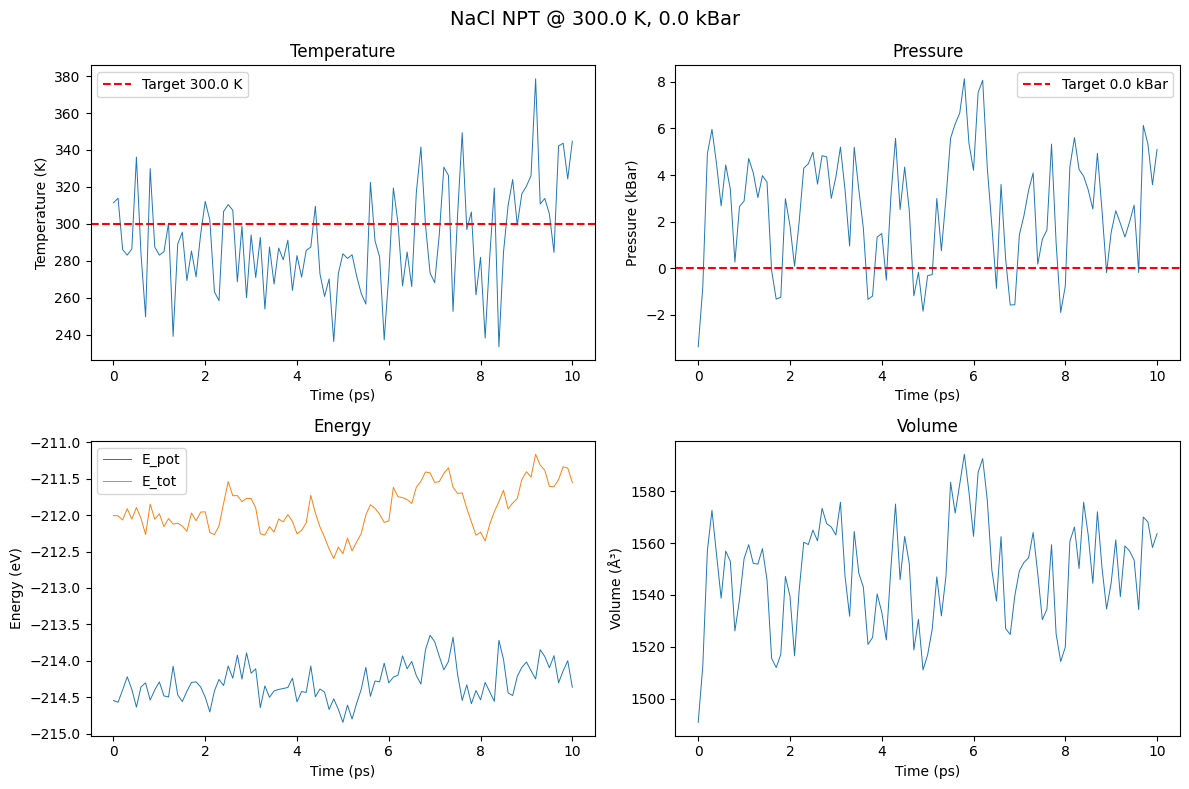

In [17]:
# --- 2×2 thermo plot ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

t = thermo["time_ps"]

axes[0, 0].plot(t, thermo["temperature_K"], lw=0.7)
axes[0, 0].axhline(T_KELVIN, color="r", ls="--", label=f"Target {T_KELVIN} K")
axes[0, 0].set(xlabel="Time (ps)", ylabel="Temperature (K)", title="Temperature")
axes[0, 0].legend()

axes[0, 1].plot(t, thermo["pressure_kbar"], lw=0.7)
axes[0, 1].axhline(P_KBAR, color="r", ls="--", label=f"Target {P_KBAR} kBar")
axes[0, 1].set(xlabel="Time (ps)", ylabel="Pressure (kBar)", title="Pressure")
axes[0, 1].legend()

axes[1, 0].plot(t, thermo["e_pot_eV"], lw=0.7, label="E_pot")
axes[1, 0].plot(t, thermo["e_tot_eV"], lw=0.7, label="E_tot")
axes[1, 0].set(xlabel="Time (ps)", ylabel="Energy (eV)", title="Energy")
axes[1, 0].legend()

axes[1, 1].plot(t, thermo["volume_A3"], lw=0.7)
axes[1, 1].set(xlabel="Time (ps)", ylabel="Volume (Å³)", title="Volume")

fig.suptitle(f"NaCl NPT @ {T_KELVIN} K, {P_KBAR} kBar", fontsize=14)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "nacl_thermo.png"), dpi=150)
plt.show()

In [18]:
# --- Equilibrium density ---
start_idx, end_idx = pick_production_window(thermo, discard_fraction=0.3)
prod_volumes = thermo["volume_A3"][start_idx:end_idx]

density = compute_density(npt_atoms, prod_volumes)
print(f"Production window: frames {start_idx}–{end_idx}")
print(f"Mean volume: {prod_volumes.mean():.2f} ± {prod_volumes.std():.2f} Å³")
print(f"Computed density: {density:.3f} g/cm³")
print("Experimental NaCl: ~2.165 g/cm³")
print(f"Deviation: {abs(density - 2.165) / 2.165 * 100:.1f}%")

Production window: frames 30–101
Mean volume: 1550.45 ± 19.95 Å³
Computed density: 2.003 g/cm³
Experimental NaCl: ~2.165 g/cm³
Deviation: 7.5%


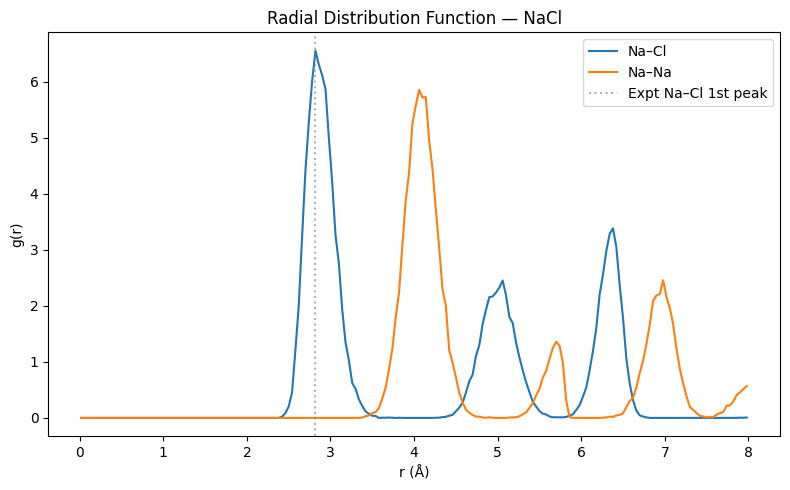

In [19]:
# --- Radial Distribution Function ---
frames = trajectory_to_ase_list(npt_atoms, npt_reply.trajectory)

# 11, 17 for Na-Cl
r_nacl, g_nacl = compute_rdf(
    frames, species_pair=(11, 17), r_max=8.0, start_frame=start_idx
)
r_nana, g_nana = compute_rdf(
    frames, species_pair=(11, 11), r_max=8.0, start_frame=start_idx
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(r_nacl, g_nacl, label="Na–Cl", lw=1.5)
ax.plot(r_nana, g_nana, label="Na–Na", lw=1.5)
ax.axvline(2.82, color="gray", ls=":", alpha=0.6, label="Expt Na–Cl 1st peak")
ax.set(xlabel="r (Å)", ylabel="g(r)", title="Radial Distribution Function — NaCl")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "nacl_rdf.png"), dpi=150)
plt.show()

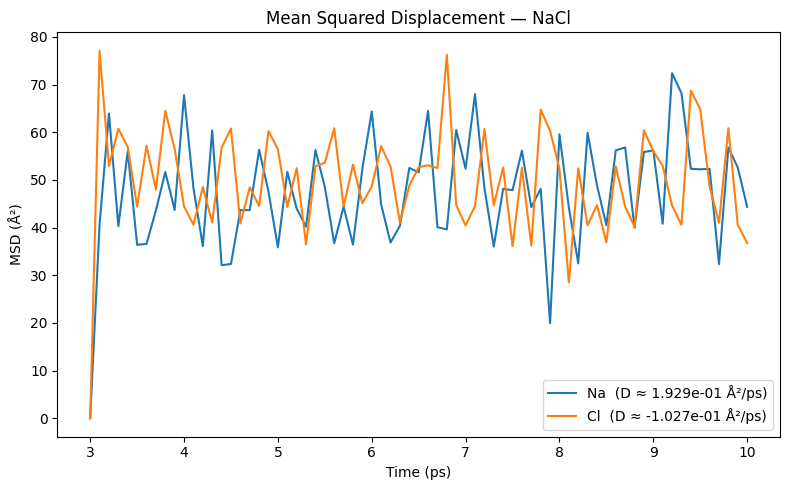

In [20]:
# --- MSD and diffusion coefficient ---
t_na, msd_na = compute_msd(frames, species=11, start_frame=start_idx)
t_cl, msd_cl = compute_msd(frames, species=17, start_frame=start_idx)

D_na = estimate_diffusion_coefficient(t_na, msd_na)
D_cl = estimate_diffusion_coefficient(t_cl, msd_cl)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t_na, msd_na, label=f"Na  (D ≈ {D_na:.3e} Å²/ps)", lw=1.5)
ax.plot(t_cl, msd_cl, label=f"Cl  (D ≈ {D_cl:.3e} Å²/ps)", lw=1.5)
ax.set(xlabel="Time (ps)", ylabel="MSD (Å²)", title="Mean Squared Displacement — NaCl")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "nacl_msd.png"), dpi=150)
plt.show()

### Thermal Expansion

The volumetric thermal expansion coefficient is defined as:

$$\alpha_V = \frac{1}{V}\left(\frac{\partial V}{\partial T}\right)_P = -\frac{1}{\rho}\left(\frac{\partial \rho}{\partial T}\right)_P$$

We estimate $\alpha_V$ by running NPT at several temperatures and fitting
$\rho(T)$.  Literature value for NaCl: $\alpha_V \approx 1.2 \times 10^{-4}\,\mathrm{K}^{-1}$.

In [21]:
##### --- Temperature sweep: concurrent NPT at multiple T ---
import importlib
import helpers
import helpers.api_client

importlib.reload(helpers.api_client)
importlib.reload(helpers)
from helpers import async_temperature_sweep  # noqa: E402

sweep_temps, sweep_densities, sweep_npt_replies = await async_temperature_sweep(
    temperatures=TEMPERATURES,
    mdatoms=nacl_md_atoms,
    server_url=BMD_SERVER_URL,
    cache_dir=CACHE_DIR,
    endpoint_live=BMD_ENDPOINT_LIVE,
    nvt_time_ps=equil_time_ps,
    npt_time_ps=prod_time_ps,
    dt=DT_FS,
    friction=FRICTION,
    pressure=P_KBAR,
    save_interval=SAVE_INTERVAL,
    timeout=1800,
    max_concurrent=len(TEMPERATURES),
)

sweep_temps = np.array(sweep_temps, dtype=float)
sweep_densities = np.array(sweep_densities)


--- T = 200 K ---
  Loading cached response: nacl_nvt_T200
  Loading cached response: nacl_npt_T200
  T=200 K → density = 2.0230 g/cm³

--- T = 250 K ---
  Loading cached response: nacl_nvt_T250
  Loading cached response: nacl_npt_T250
  T=250 K → density = 2.0119 g/cm³

--- T = 300 K ---
  Loading cached response: nacl_nvt_T300
  Loading cached response: nacl_npt_T300
  T=300 K → density = 1.9914 g/cm³

--- T = 350 K ---
  Loading cached response: nacl_nvt_T350
  Loading cached response: nacl_npt_T350
  T=350 K → density = 1.9784 g/cm³

--- T = 400 K ---
  Loading cached response: nacl_nvt_T400
  Loading cached response: nacl_npt_T400
  T=400 K → density = 1.9664 g/cm³

--- T = 450 K ---
  Loading cached response: nacl_nvt_T450
  Loading cached response: nacl_npt_T450
  T=450 K → density = 1.9500 g/cm³

--- T = 500 K ---
  Loading cached response: nacl_nvt_T500
  Loading cached response: nacl_npt_T500
  T=500 K → density = 1.9410 g/cm³


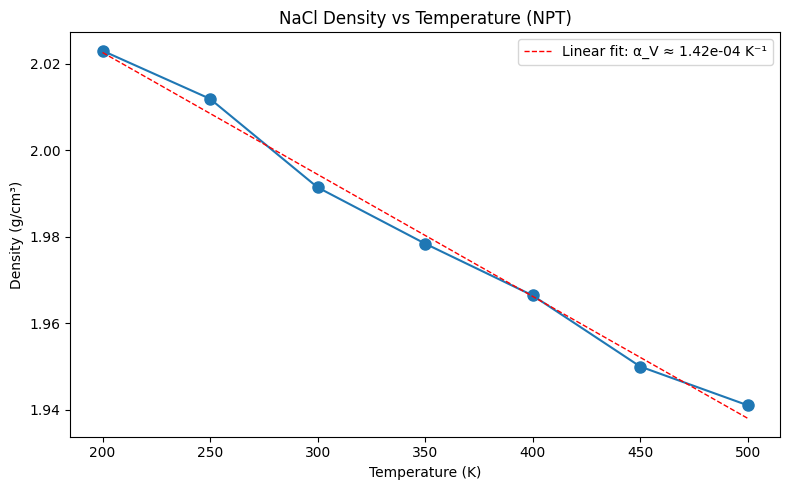

Estimated α_V = 1.42e-04 K⁻¹
Literature NaCl: ~1.2e-4 K⁻¹


In [22]:
# --- Plot density vs temperature and estimate alpha_V ---
alpha_v = thermal_expansion_proxy(sweep_temps, sweep_densities)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sweep_temps, sweep_densities, "o-", lw=1.5, markersize=8)
ax.set(
    xlabel="Temperature (K)",
    ylabel="Density (g/cm³)",
    title="NaCl Density vs Temperature (NPT)",
)

# Linear fit overlay
fit = np.polyfit(sweep_temps, sweep_densities, 1)
ax.plot(
    sweep_temps,
    np.polyval(fit, sweep_temps),
    "r--",
    lw=1,
    label=f"Linear fit: α_V ≈ {alpha_v:.2e} K⁻¹",
)
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "nacl_thermal_expansion.png"), dpi=150)
plt.show()

print(f"Estimated α_V = {alpha_v:.2e} K⁻¹")
print("Literature NaCl: ~1.2e-4 K⁻¹")

---
## 6. Summary

In this playbook we demonstrated:

1. **Endpoint connectivity** — health check, schema walkthrough, H₂ hello world
2. **Structure preparation** — pymatgen unit cell → supercell → MDAtomicData
3. **NVT/NPT molecular dynamics** — Langevin thermostat + MC barostat via REST API
4. **Thermodynamic extraction** — T, P, E, V time series; density; RDF; MSD
5. **Temperature sweep** — batched NPT → thermal expansion coefficient

### Next Steps

- **Switch MLIPs**: Restart the NIM with `--model sevennet` or `--model orb` — no client changes needed
- **Scale up**: Use `asyncio` for concurrent batch submissions
- **Conformer stability**: See the companion playbook `alchemi-conformer-stability.ipynb` for UDC-inspired OLED screening workflows
- **Free energy**: Combine temperature sweeps with thermodynamic integration
- **Visualise trajectories**: Export to OVITO for animated GIF/video rendering